# Unusual density profiles

The Earth is one profile among many. `slabs` takes any sequence of widths and Hamiltonians, so a profile can be built by hand — and some of the interesting ones are not remotely Earth-like.

The point of this notebook is that the *shape* of the profile matters, not only its average. A castle wall and a uniform slab of the same mean density give different probabilities, sometimes very different.

In [1]:
import sys
import os

# Works whether or not the package is installed: these notebooks sit one
# level below the repository root, so src/ is one directory up.
sys.path.insert(0, os.path.abspath(os.path.join('..', 'src')))

import numpy as np
import matplotlib.pyplot as plt

import globaldefs as gd
import oscprob2nu
import oscprob3nu
import oscprob4nu
import hamiltonians2nu
import hamiltonians3nu
import hamiltonians4nu

%matplotlib inline
plt.rcParams.update({'figure.figsize': (7.2, 4.2), 'figure.dpi': 90,
                     'axes.grid': True, 'grid.alpha': 0.3,
                     'font.size': 11, 'legend.frameon': False,
                     # Axes end exactly at the data: no padding beyond
                     # x_min/x_max or y_min/y_max.
                     'axes.xmargin': 0.0, 'axes.ymargin': 0.0})

# The three-flavor vacuum Hamiltonian at the NuFit best fit, normal ordering.
# It is energy-independent; dividing by the energy is what the builders do.
H_VAC_3NU = hamiltonians3nu.hamiltonian_3nu_vacuum_energy_independent(
    gd.S12_NO_BF, gd.S23_NO_BF, gd.S13_NO_BF, gd.DCP_NO_BF,
    gd.D21_NO_BF, gd.D31_NO_BF)

KM = gd.CONV_KM_TO_INV_EV      # multiply a length in km to get eV^-1
GEV = 1.0e9                    # multiply an energy in GeV to get eV

In [2]:
import earth
import slabs

In [3]:
def probabilities_profile(widths_km, densities, energy_ev,
                          h_vac=None):
    """Nine probabilities through an arbitrary matter profile.

    `energy_ev` may be an array, in which case the whole scan
    is one call: the Hamiltonians stack on a leading axis and
    `slabs` composes every chord in a single pass.
    """
    h_vac = H_VAC_3NU if h_vac is None else h_vac
    vcc = earth.matter_potential(np.asarray(densities, dtype=float))
    energy = np.asarray(energy_ev, dtype=float)
    if energy.ndim:
        energy = energy[:, None]   # one chord per energy
    H = hamiltonians3nu.hamiltonian_3nu_matter(h_vac, energy, vcc)
    return np.array(slabs.probabilities_3nu_slabs(
        H, np.asarray(widths_km, dtype=float)*KM))


def show_profile(ax, widths_km, densities, **kw):
    """Draws a profile as the step function it is."""
    edges = np.concatenate(([0.0], np.cumsum(widths_km)))
    ax.step(edges, np.concatenate((densities[:1], densities)),
            where="pre", **kw)
    ax.set_xlim(0.0, edges[-1])

## Three profiles, one mean density

A **castle wall** alternates between two densities. A **serrated** profile ramps up in steps and drops back. A **random** wall keeps the same two levels but shuffles them. All three below have the same total length and the same mean density as the uniform case, so any difference in the probabilities is due to the arrangement alone.

In [4]:
total_km = 6000.0
n_slab = 24
rho_lo, rho_hi = 2.0, 8.0
mean_rho = 0.5*(rho_lo+rho_hi)

widths = np.full(n_slab, total_km/n_slab)

castle = np.where(np.arange(n_slab) % 2 == 0, rho_lo, rho_hi)
serrated = np.tile(np.linspace(rho_lo, rho_hi, 6), 4)
rng = np.random.default_rng(20260801)
# A *permutation* of the castle wall, not a fresh random draw: that
# guarantees the identical multiset of slabs, and so exactly the
# same mean density, which is the whole premise of the comparison.
random_wall = rng.permutation(castle)
uniform = np.full(n_slab, mean_rho)

profiles = [("castle wall", castle),
            ("serrated", serrated),
            ("random wall", random_wall),
            ("uniform", uniform)]

for name, rho in profiles:
    print("%-12s mean = %.3f g/cm^3" % (name, rho.mean()))

castle wall  mean = 5.000 g/cm^3
serrated     mean = 5.000 g/cm^3
random wall  mean = 5.000 g/cm^3
uniform      mean = 5.000 g/cm^3


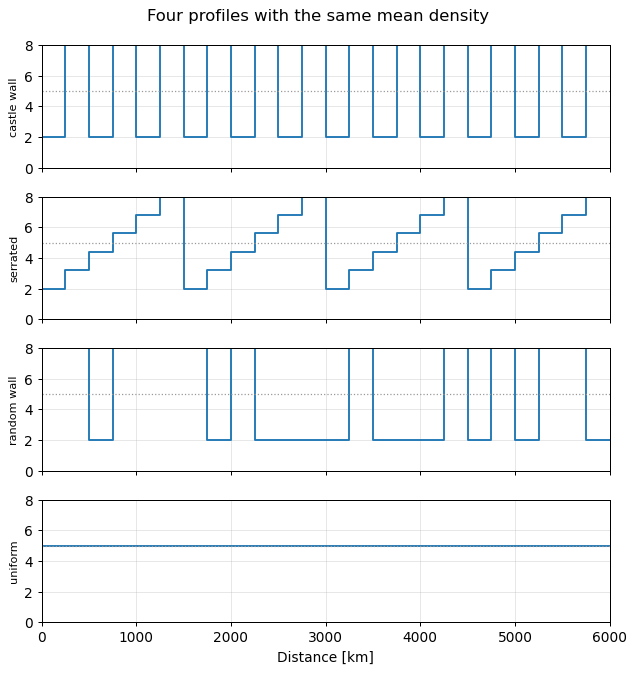

In [5]:
fig, axes = plt.subplots(4, 1, figsize=(7.2, 7.6), sharex=True)
for ax, (name, rho) in zip(axes, profiles):
    show_profile(ax, widths, rho, color="C0")
    ax.axhline(mean_rho, color="0.6", ls=":", lw=1)
    ax.set_ylabel(name, fontsize=9)
    ax.set_ylim(0.0, rho_hi*1.0)
axes[-1].set_xlabel("Distance [km]")
fig.suptitle("Four profiles with the same mean density")
fig.tight_layout()
plt.show()

## The probabilities they produce

Scanning energy through each profile. Where the curves separate, the arrangement of the matter is doing the work — the mean density is identical throughout.

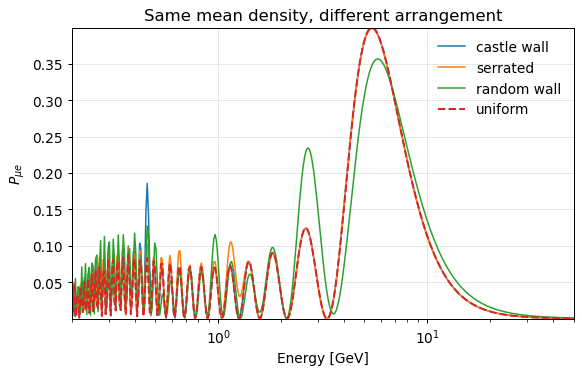

In [6]:
E_gev = np.logspace(-0.7, 1.7, 400)

fig, ax = plt.subplots()
for name, rho in profiles:
    # All 400 energies in one call, not one call each
    p = probabilities_profile(widths, rho, E_gev*GEV)[:, 3]
    ax.semilogx(E_gev, p, label=name,
                lw=1.6 if name == "uniform" else 1.2,
                ls="--" if name == "uniform" else "-")
ax.set_xlim(E_gev[0], E_gev[-1])
ax.set_xlabel("Energy [GeV]")
ax.set_ylabel(r"$P_{\mu e}$")
ax.set_title("Same mean density, different arrangement")
ax.legend()
plt.show()

## One call for the whole scan

The curves above were not drawn one energy at a time. Every routine in `slabs` takes a *batch* of chords: Hamiltonians of shape `(..., n_slabs, n, n)` against the one set of widths the chords share, returning one row of probabilities per chord.

That is the shape an energy scan already has. `hamiltonian_3nu_matter` broadcasts an array of energies against an array of per-slab potentials and hands back exactly it, so the stacking costs nothing to write.

The geometry is what is shared, so this is the right tool for a scan over energy at a fixed profile — and the wrong one for a scan over zenith angle, where every chord has its own widths. For that, `earth.probabilities_3nu_earth` takes energies and angles on separate axes and handles the bookkeeping.

In [7]:
import timeit

rho = dict(profiles)["castle wall"]
E_scan = np.logspace(-0.7, 1.7, 400)*GEV

# One call: (400, 24, 3, 3) Hamiltonians, 24 shared widths
vcc = earth.matter_potential(rho)
H_batch = hamiltonians3nu.hamiltonian_3nu_matter(
    H_VAC_3NU, E_scan[:, None], vcc)
print("stack of Hamiltonians:", H_batch.shape)

batched = np.array(slabs.probabilities_3nu_slabs(
    H_batch, widths*KM))
print("probabilities        :", batched.shape)

# The loop it replaces
looped = np.array([
    slabs.probabilities_3nu_slabs(
        hamiltonians3nu.hamiltonian_3nu_matter(H_VAC_3NU, e, vcc),
        widths*KM)
    for e in E_scan])

print("largest difference   : %.1e"
      % np.abs(batched-looped).max())

t_batch = timeit.timeit(
    lambda: slabs.probabilities_3nu_slabs(H_batch, widths*KM),
    number=20)/20
t_loop = timeit.timeit(
    lambda: [slabs.probabilities_3nu_slabs(h, widths*KM)
             for h in H_batch],
    number=3)/3
print("batched: %6.2f ms" % (1e3*t_batch))
print("looped : %6.2f ms  (%.0fx)"
      % (1e3*t_loop, t_loop/t_batch))

stack of Hamiltonians: (400, 24, 3, 3)
probabilities        : (400, 9)
largest difference   : 4.4e-16
batched:   0.35 ms
looped :   4.42 ms  (13x)


The two agree to round-off rather than bit for bit: they take different paths through the compiled backend. What they do not differ in is the physics — nothing is approximated by either.

## Parametric enhancement

A castle wall is not an arbitrary choice. When the width of one period is tuned against the oscillation length, successive layers add coherently and the transition probability can be driven far above what either density gives on its own — a parametric resonance. Sweeping the number of periods at fixed total length shows it building up.

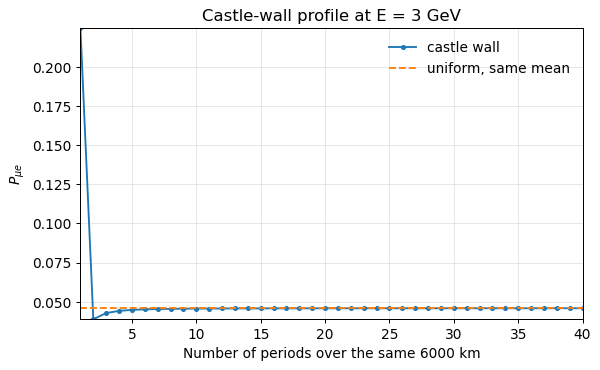

In [8]:
E_fixed = 3.0*GEV
periods = np.arange(1, 41)

p_castle, p_uniform = [], []
for n_period in periods:
    n = 2*n_period
    w = np.full(n, total_km/n)
    rho = np.where(np.arange(n) % 2 == 0, rho_lo, rho_hi)
    p_castle.append(probabilities_profile(w, rho, E_fixed)[3])
    p_uniform.append(probabilities_profile(
        w, np.full(n, mean_rho), E_fixed)[3])

fig, ax = plt.subplots()
ax.plot(periods, p_castle, "o-", ms=3, label="castle wall")
ax.plot(periods, p_uniform, "--", label="uniform, same mean")
ax.set_xlim(periods[0], periods[-1])
ax.set_xlabel("Number of periods over the same 6000 km")
ax.set_ylabel(r"$P_{\mu e}$")
ax.set_title("Castle-wall profile at E = 3 GeV")
ax.legend()
plt.show()

## Sensitivity to the arrangement

Twenty random walls, all with the same two densities and the same mean. The spread between them is a direct measure of how much the ordering matters at this energy.

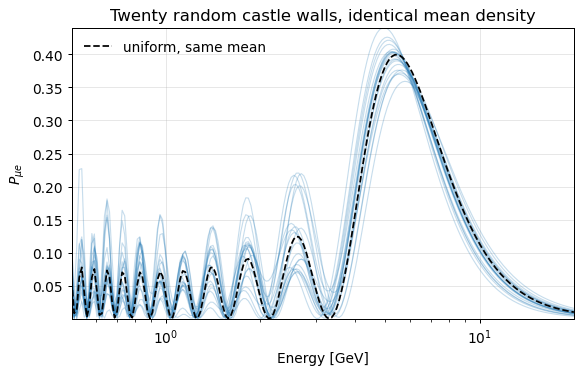

In [9]:
E_fixed = 3.0*GEV
rng = np.random.default_rng(7)

curves = []
E_gev = np.logspace(-0.3, 1.3, 200)
for _ in range(20):
    rho = rng.permutation(castle)
    curves.append([probabilities_profile(widths, rho, e*GEV)[3]
                   for e in E_gev])
curves = np.array(curves)

fig, ax = plt.subplots()
ax.semilogx(E_gev, curves.T, color="C0", alpha=0.25, lw=0.9)
ax.semilogx(E_gev, [probabilities_profile(
    widths, uniform, e*GEV)[3] for e in E_gev],
    "k--", lw=1.4, label="uniform, same mean")
ax.set_xlim(E_gev[0], E_gev[-1])
ax.set_xlabel("Energy [GeV]")
ax.set_ylabel(r"$P_{\mu e}$")
ax.set_title("Twenty random castle walls, identical mean density")
ax.legend()
plt.show()

Every curve above is exact. Nothing here is a perturbative or adiabatic approximation: each slab is solved in closed form and the operators are multiplied, so the only thing separating these results from the continuum is how the profile itself was defined.

---

**Previous:** [Probabilities through the Earth](07_earth_probabilities.ipynb)  
**Next:** [Performance](09_performance.ipynb) --- looping versus broadcasting, measured on your machine  
[API reference](https://mbustama.github.io/NuOscProbExact/functions.html) &middot; [Numerical recipes](https://mbustama.github.io/NuOscProbExact/recipes.html) &middot; [All notebooks](.)